# 1. IMPORT

In [1]:
# CELL 1: Imports (Optimized for Pure EDA)
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageChops, ImageStat
from skimage.feature import local_binary_pattern
import warnings
import random

warnings.filterwarnings('ignore')

print("IMPORT OK")
print(f"- NumPy: {np.__version__}")
print(f"- OpenCV: {cv2.__version__}")

IMPORT OK
- NumPy: 2.0.2
- OpenCV: 4.13.0


# 2. CONFIG

In [2]:
CONFIG = {
    "BASE_PATH": "/kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1",
    "IMG_SIZE": (256, 256),
    "SEED": 42,
    
    "ELA_QUALITY": 90,

    "LBP_RADIUS": 1,
    "LBP_POINTS": 8,
    "LBP_METHOD": "uniform"
}

CONFIG["TRAIN_DIR"] = os.path.join(CONFIG["BASE_PATH"], "train")
CONFIG["VALID_DIR"] = os.path.join(CONFIG["BASE_PATH"], "validation")
CONFIG["TEST_DIR"] = os.path.join(CONFIG["BASE_PATH"], "test")

print("CONFIG OK")
for key, value in CONFIG.items():
    print(f"- {key}: {value}")
    

CONFIG OK
- BASE_PATH: /kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1
- IMG_SIZE: (256, 256)
- SEED: 42
- ELA_QUALITY: 90
- LBP_RADIUS: 1
- LBP_POINTS: 8
- LBP_METHOD: uniform
- TRAIN_DIR: /kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1/train
- VALID_DIR: /kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1/validation
- TEST_DIR: /kaggle/input/datasets/shivamardeshna/real-and-fake-images-dataset-for-image-forensics/Data Set 1/Data Set 1/test


# 3. LOAD DATA - OVERVIEW

In [3]:
def get_image_paths(directory):
    fake_paths = []
    real_paths = []
    
    if os.path.exists(directory):
        for class_name in os.listdir(directory):
            class_dir = os.path.join(directory, class_name)
            if not os.path.isdir(class_dir):
                continue
 
            valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp')
            if class_name.lower() == 'fake':
                fake_paths = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
            elif class_name.lower() == 'real':
                real_paths = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.lower().endswith(valid_extensions)]
                
    return fake_paths, real_paths

train_fake, train_real = get_image_paths(CONFIG["TRAIN_DIR"])
valid_fake, valid_real = get_image_paths(CONFIG["VALID_DIR"])
test_fake, test_real = get_image_paths(CONFIG["TEST_DIR"])

CONFIG["TRAIN_PATHS"] = {"FAKE": train_fake, "REAL": train_real}

h, w = CONFIG["IMG_SIZE"]
c = 3 

print("Dataset Shapes (Samples, Height, Width, Channels):")
print("-" * 65)
print(f"TRAIN : ({len(train_fake) + len(train_real)}, {h}, {w}, {c}) -> FAKE: {len(train_fake)} | REAL: {len(train_real)}")
print(f"VALID : ({len(valid_fake) + len(valid_real)}, {h}, {w}, {c}) -> FAKE: {len(valid_fake)} | REAL: {len(valid_real)}")
print(f"TEST  : ({len(test_fake) + len(test_real)}, {h}, {w}, {c}) -> FAKE: {len(test_fake)} | REAL: {len(test_real)}")


Dataset Shapes (Samples, Height, Width, Channels):
-----------------------------------------------------------------
TRAIN : (40002, 256, 256, 3) -> FAKE: 20001 | REAL: 20001
VALID : (12360, 256, 256, 3) -> FAKE: 6161 | REAL: 6199
TEST  : (5227, 256, 256, 3) -> FAKE: 2623 | REAL: 2604


# 4. VISUALIZATION

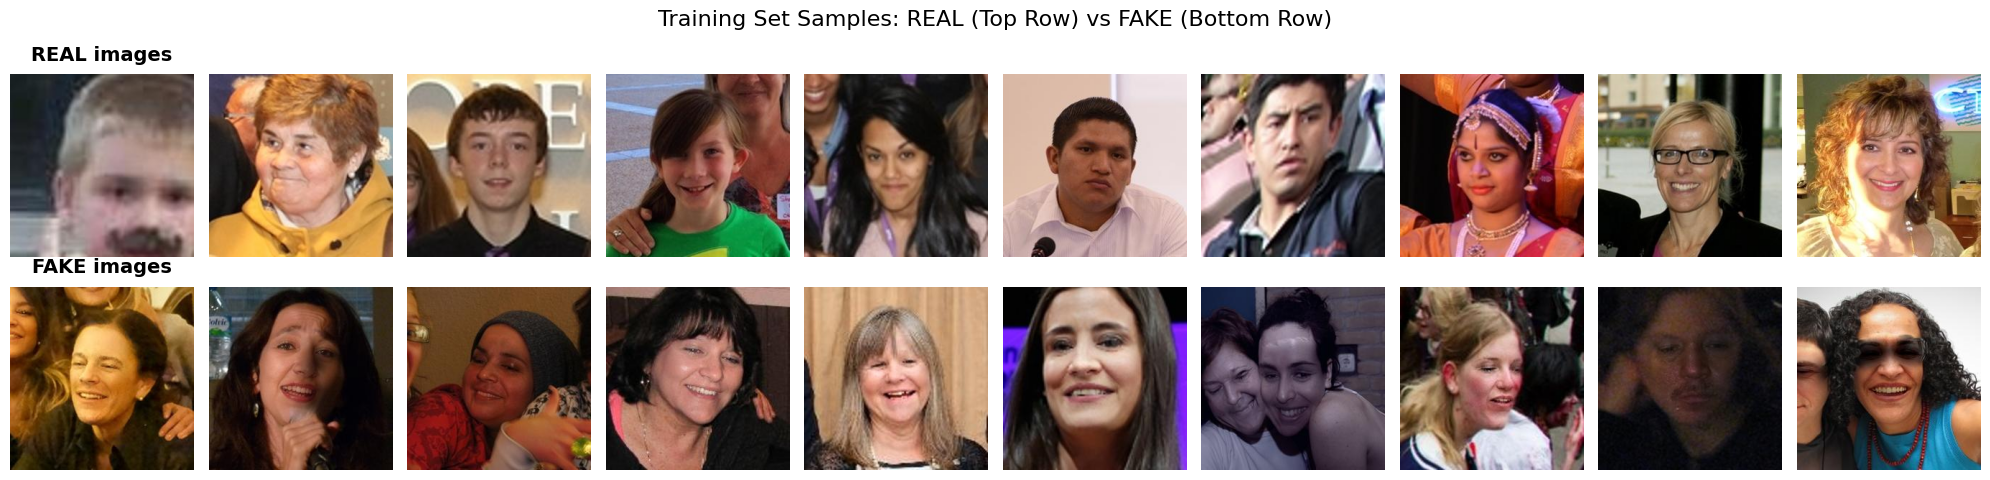

In [4]:
def plot_samples(real_paths, fake_paths, num_samples=10):
    random.seed(CONFIG["SEED"])
    
    sampled_real = random.sample(real_paths, num_samples)
    sampled_fake = random.sample(fake_paths, num_samples)
    
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 5))
    fig.suptitle("Training Set Samples: REAL (Top Row) vs FAKE (Bottom Row)", fontsize=16)
    
    for i in range(num_samples):
        real_img = cv2.imread(sampled_real[i])
        real_img = cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB) 
        axes[0, i].imshow(real_img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title("REAL images", fontsize=14, fontweight='bold', pad=10)
 
        fake_img = cv2.imread(sampled_fake[i])
        fake_img = cv2.cvtColor(fake_img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(fake_img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title("FAKE images", fontsize=14, fontweight='bold', pad=10)
            
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

plot_samples(CONFIG["TRAIN_PATHS"]["REAL"], CONFIG["TRAIN_PATHS"]["FAKE"], num_samples=10)


# 5. EDA to Feature Engineering

## 5.1. ELA - Error Level Analysis

Processing REAL images:   0%|          | 0/20001 [00:00<?, ?it/s]

Processing FAKE images:   0%|          | 0/20001 [00:00<?, ?it/s]

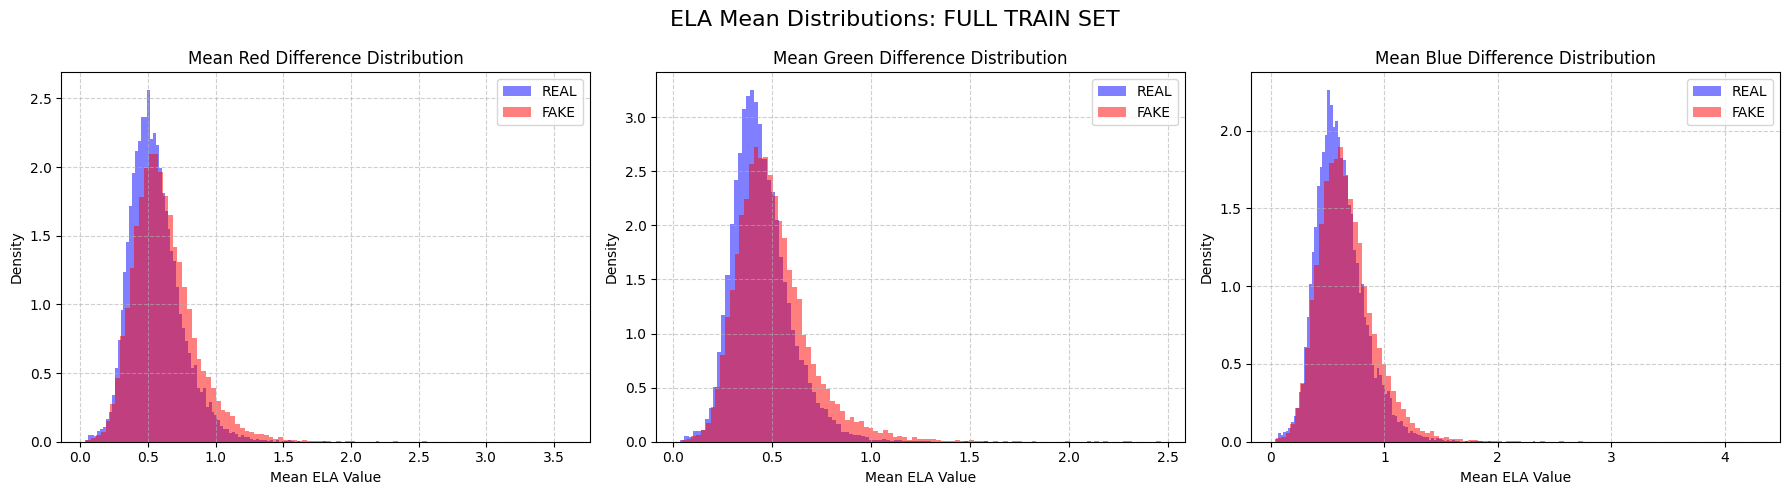

In [5]:
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm


def get_ela_means(img_path, quality=CONFIG["ELA_QUALITY"]):
    img = cv2.imread(img_path)
    if img is None: 
        return img_path, None
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encoded_img = cv2.imencode('.jpg', img, encode_param)
    recompressed = cv2.imdecode(encoded_img, 1)
    recompressed_rgb = cv2.cvtColor(recompressed, cv2.COLOR_BGR2RGB)
    
    diff = np.abs(img_rgb.astype(np.int16) - recompressed_rgb.astype(np.int16))
    return img_path, np.mean(diff, axis=(0, 1))

def process_paths_parallel(paths, desc):
    results = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = executor.map(get_ela_means, paths)
        for path, means in tqdm(futures, total=len(paths), desc=desc):
            if means is not None:
                results.append(means)
    return np.array(results)

real_means = process_paths_parallel(CONFIG["TRAIN_PATHS"]["REAL"], desc="Processing REAL images")
fake_means = process_paths_parallel(CONFIG["TRAIN_PATHS"]["FAKE"], desc="Processing FAKE images")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ELA Mean Distributions: FULL TRAIN SET", fontsize=16)

channels = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

for i, (channel, color) in enumerate(zip(channels, colors)):
    axes[i].hist(real_means[:, i], bins=100, alpha=0.5, label='REAL', color='blue', density=True)
    axes[i].hist(fake_means[:, i], bins=100, alpha=0.5, label='FAKE', color='red', density=True)
    
    axes[i].set_title(f'Mean {channel} Difference Distribution')
    axes[i].set_xlabel('Mean ELA Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# REPORT

*   **Vùng Xanh dương (Chỉ REAL):** Mức độ nén tự nhiên của ảnh gốc.
*   **Vùng Cam (Chỉ FAKE):** Mức độ lỗi nén bất thường, đặc trưng của ảnh đã qua thao tác (Splicing/Retouching).
*   **Vùng Đỏ sẫm / Tím (Vùng chồng lấp - Overlap):** Đây là khu vực mà phân phối của ảnh REAL và FAKE giao nhau. 

---

## 1. ELA Distribution

Dựa vào ba biểu đồ Histogram phân phối giá trị trung bình (Mean) ELA cho các kênh màu Đỏ (Red), Xanh lục (Green) và Xanh lam (Blue), nhóm em rút ra các quan sát thống kê cụ thể:

*   **Tính chất chồng chéo (Overlapping):** Phân phối của cả hai nhãn REAL (xanh dương) và FAKE (đỏ) đều có dạng hình chuông và chồng lấp lên nhau (đỏ đậm) khá nhiều ở dải giá trị Mean ELA thấp (trọng tâm từ 0.3 đến 0.8). 
*   **Độ lệch phải và mật độ vùng đuôi (Right-skewed Tail Density):** Dấu hiệu phân biệt cốt lõi nằm ở hình dáng phần đuôi của phân phối. Trên cả ba kênh màu, phổ của ảnh FAKE có xu hướng kéo dài và có mật độ (density) dày hơn hẳn ở phía bên phải (vùng có giá trị Mean ELA > 1.0). 
*   **Sự dịch chuyển của đỉnh phổ (Peak Shift):** Đỉnh của phân phối ảnh FAKE thấp hơn và có xu hướng dịch chuyển nhẹ về phía giá trị cao hơn so với đỉnh của phân phối ảnh REAL.

---

## 2. Feature Engineering - ELA

Nhóm chọn ELA làm một trong những feature chủ chốt cho bài toán này vì các lý do sau:

*   **Định lượng Artifact nén phi tự nhiên:** Các bức ảnh FAKE (đặc biệt là ảnh cắt ghép - Spliced hoặc đã qua chỉnh sửa cục bộ) chứa các vùng pixel có lịch sử nén JPEG khác nhau. Khi bức ảnh giả mạo này được lưu lại, nó trải qua quá trình nén lần thứ hai (recompression). Những vùng bị can thiệp sẽ bộc lộ mức chênh lệch lỗi (Error Level) bất thường so với nền gốc. Việc tính toán `|original - recompressed|` giúp làm nổi bật tín hiệu thao túng này.
*   **Giá trị thống kê có độ tin cậy cao:** Biểu đồ mật độ trên 40.002 tấm ảnh đã chứng minh bằng toán học rằng các thao tác chỉnh sửa đã đẩy mức lỗi nén trung bình của ảnh FAKE lên cao hơn (thể hiện qua phần đuôi lệch phải).
*   **Khả năng kết hợp trong không gian đa chiều:** Mặc dù chỉ dựa vào đặc trưng Mean ELA là không đủ để phân tách hoàn hảo hai lớp dữ liệu (do sự chồng chéo ở vùng đỉnh), nhưng khi nó được đẩy vào một vector đặc trưng kết hợp cùng phương sai (Std), giá trị cực đại (Max) và các đặc trưng miền tần số/kết cấu (FFT, LBP), mô hình phân lớp sẽ có đủ thông tin để thiết lập một ranh giới quyết định (decision boundary) chính xác cao.

## 5.2. FFT - Fast Fourrier Transform

FFT REAL images:   0%|          | 0/20001 [00:00<?, ?it/s]

FFT FAKE images:   0%|          | 0/20001 [00:00<?, ?it/s]

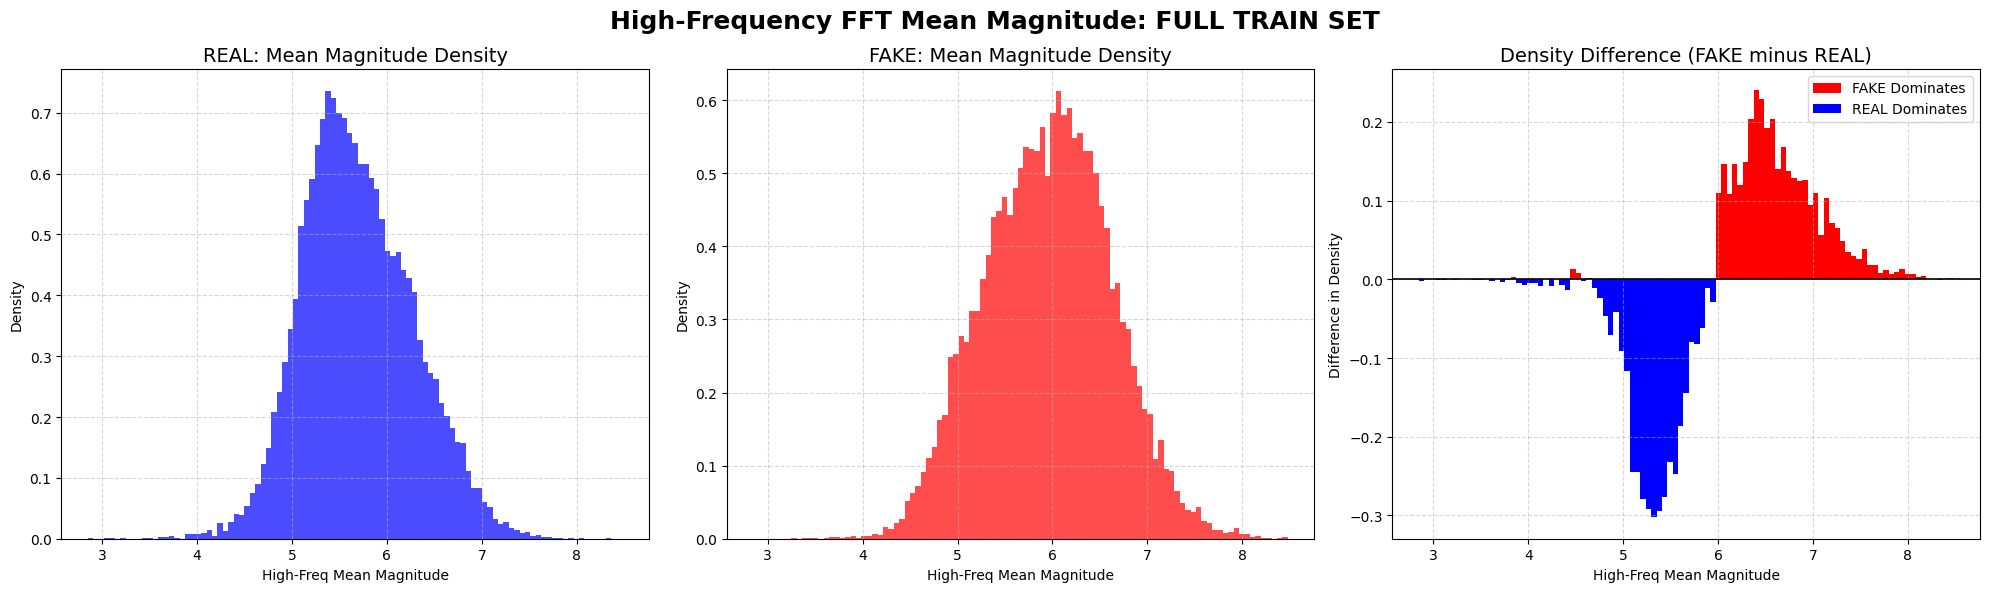

In [6]:
H, W = CONFIG["IMG_SIZE"]
CY, CX = H // 2, W // 2
Y, X = np.ogrid[:H, :W]
DIST_FROM_CENTER = np.sqrt((X - CX)**2 + (Y - CY)**2)
MASK_HIGH = DIST_FROM_CENTER > 85

def get_high_freq_fft_mean(img_path):
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return img_path, None
        
    f_transform = np.fft.fft2(img_gray)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.log(1 + np.abs(f_shift))
    
    hf_mean = np.mean(magnitude_spectrum[MASK_HIGH])
    return img_path, hf_mean

def process_fft_parallel(paths, desc):
    results = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = executor.map(get_high_freq_fft_mean, paths)
        for path, val in tqdm(futures, total=len(paths), desc=desc):
            if val is not None:
                results.append(val)
    return np.array(results)


real_fft_means = process_fft_parallel(CONFIG["TRAIN_PATHS"]["REAL"], desc="FFT REAL images")
fake_fft_means = process_fft_parallel(CONFIG["TRAIN_PATHS"]["FAKE"], desc="FFT FAKE images")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("High-Frequency FFT Mean Magnitude: FULL TRAIN SET", fontsize=18, fontweight='bold')

min_val = min(np.min(real_fft_means), np.min(fake_fft_means))
max_val = max(np.max(real_fft_means), np.max(fake_fft_means))
bins = np.linspace(min_val, max_val, 100)

hist_real, _ = np.histogram(real_fft_means, bins=bins, density=True)
hist_fake, _ = np.histogram(fake_fft_means, bins=bins, density=True)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

axes[0].bar(bin_centers, hist_real, width=(bins[1]-bins[0]), color='blue', alpha=0.7)
axes[0].set_title('REAL: Mean Magnitude Density', fontsize=14)
axes[0].set_xlabel('High-Freq Mean Magnitude')
axes[0].set_ylabel('Density')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].bar(bin_centers, hist_fake, width=(bins[1]-bins[0]), color='red', alpha=0.7)
axes[1].set_title('FAKE: Mean Magnitude Density', fontsize=14)
axes[1].set_xlabel('High-Freq Mean Magnitude')
axes[1].set_ylabel('Density')
axes[1].grid(True, linestyle='--', alpha=0.5)

diff = hist_fake - hist_real
colors = ['red' if d > 0 else 'blue' for d in diff]

axes[2].bar(bin_centers, diff, width=(bins[1]-bins[0]), color=colors)
axes[2].axhline(0, color='black', linewidth=1.2)
axes[2].set_title('Density Difference (FAKE minus REAL)', fontsize=14)
axes[2].set_xlabel('High-Freq Mean Magnitude')
axes[2].set_ylabel('Difference in Density')
axes[2].grid(True, linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='FAKE Dominates'),
                   Patch(facecolor='blue', label='REAL Dominates')]
axes[2].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

### High-Frequency FFT

Dựa vào 3 biểu đồ phân phối **High-Freq Mean Magnitude**, nhóm em có những kết luận sau:

## **1. Sự dịch chuyển phân phối (Distribution Shift):**
*   **Ảnh REAL (Biểu đồ trái):** Phân phối tập trung mạnh và đạt đỉnh ở dải giá trị thấp, dao động quanh mức **5.4 - 5.6**. Điều này phản ánh tính chất mượt mà, chuyển màu liên tục tự nhiên của các điểm ảnh trong thế giới thực.
*   **Ảnh FAKE (Biểu đồ giữa):** Toàn bộ hình chuông phân phối bị đẩy mạnh về phía bên phải, đạt đỉnh ở mức **6.0 - 6.2** và phổ dữ liệu rộng hơn. 

--- 

## **2. Domain Knowledge:**
Sự gia tăng đột biến của dải tần số cao trong ảnh FAKE hoàn toàn khớp với lý thuyết thị giác máy tính. Các thao tác ngụy tạo (như cắt ghép cục bộ, viền ranh giới giả mạo) hoặc lưới nhiễu (checkerboard artifacts) từ các mô hình AI sinh ảnh luôn để lại các **bất liên tục vi mô (micro-discontinuities)**. 

---

**3. Ranh giới quyết định sắc bén (Biểu đồ hiệu số - Phải):**
Biểu đồ "Density Difference" (FAKE minus REAL) là minh chứng rõ ràng nhất cho sức mạnh của đặc trưng này, vượt trội hơn hẳn so với ELA ở khả năng phân tách. Nó chia không gian dữ liệu thành hai vùng đối lập rõ rệt với điểm giao cắt (zero-crossing) nằm quanh ngưỡng **5.8 - 5.9**:
*   **Vùng Xanh dương (REAL Dominates - Dưới 5.8):** Nơi mật độ ảnh thật áp đảo hoàn toàn.
*   **Vùng Đỏ (FAKE Dominates - Trên 5.9):** Mức độ chênh lệch rất mạnh chứng tỏ dải giá trị từ 6.0 trở lên gần như là đặc điểm nhận diện của ảnh FAKE.


## 5.3. LBP - Local Binary Pattern

LBP REAL images:   0%|          | 0/20001 [00:00<?, ?it/s]

LBP FAKE images:   0%|          | 0/20001 [00:00<?, ?it/s]

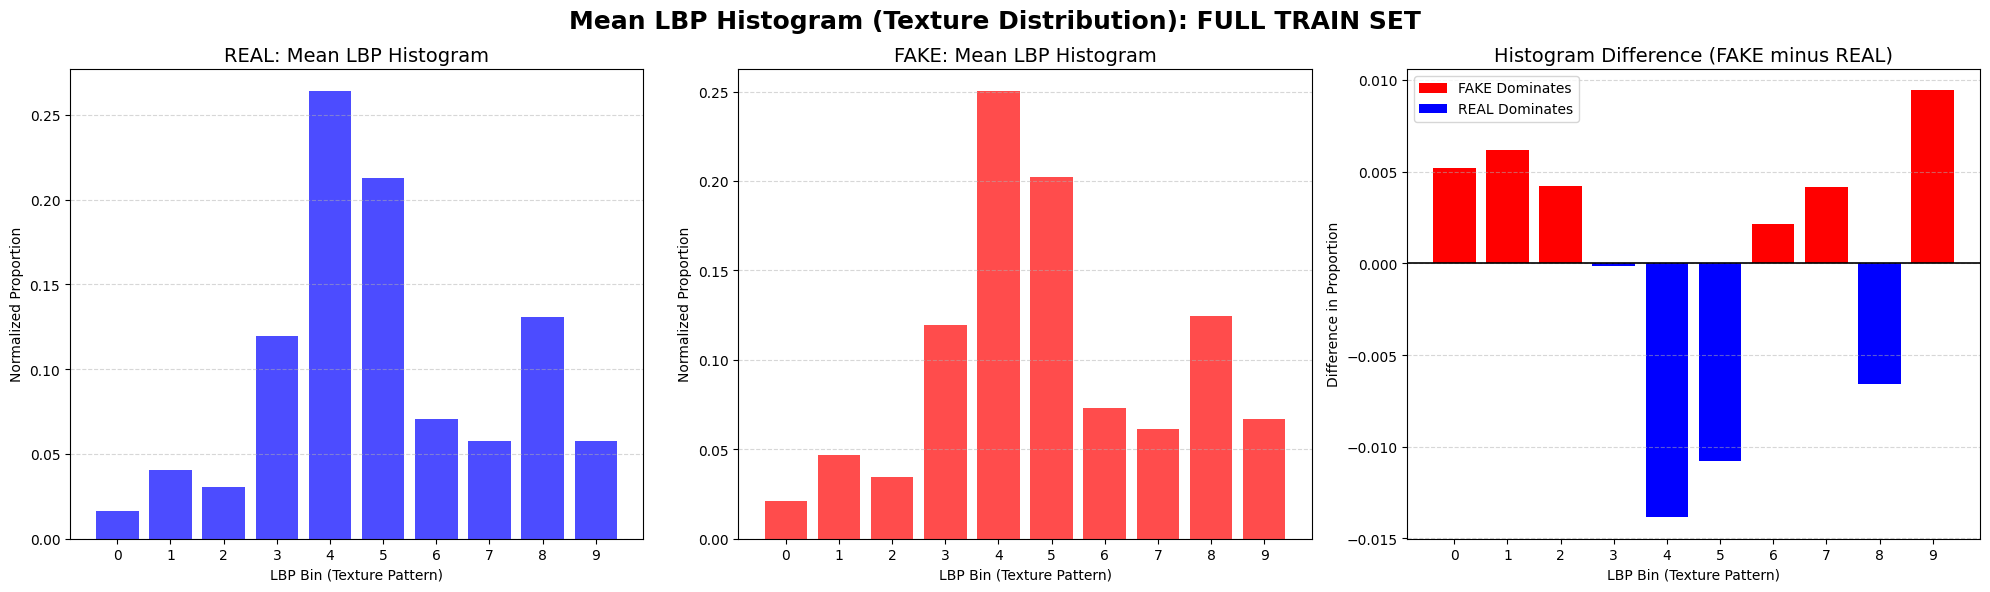

In [7]:
def get_lbp_histogram(img_path):
    img_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img_gray is None:
        return None

    lbp = local_binary_pattern(img_gray, 
                               P=CONFIG["LBP_POINTS"], 
                               R=CONFIG["LBP_RADIUS"], 
                               method=CONFIG["LBP_METHOD"])
    
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10), density=True)
    return hist

def process_lbp_parallel(paths, desc):
    histograms = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = executor.map(get_lbp_histogram, paths)
        for hist in tqdm(futures, total=len(paths), desc=desc):
            if hist is not None:
                histograms.append(hist)
    return np.mean(np.array(histograms), axis=0)

real_lbp_mean_hist = process_lbp_parallel(CONFIG["TRAIN_PATHS"]["REAL"], desc="LBP REAL images")
fake_lbp_mean_hist = process_lbp_parallel(CONFIG["TRAIN_PATHS"]["FAKE"], desc="LBP FAKE images")

bins = np.arange(10)
width = 0.8

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Mean LBP Histogram (Texture Distribution): FULL TRAIN SET", fontsize=18, fontweight='bold')

axes[0].bar(bins, real_lbp_mean_hist, width=width, color='blue', alpha=0.7)
axes[0].set_title('REAL: Mean LBP Histogram', fontsize=14)
axes[0].set_xlabel('LBP Bin (Texture Pattern)')
axes[0].set_ylabel('Normalized Proportion')
axes[0].set_xticks(bins)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].bar(bins, fake_lbp_mean_hist, width=width, color='red', alpha=0.7)
axes[1].set_title('FAKE: Mean LBP Histogram', fontsize=14)
axes[1].set_xlabel('LBP Bin (Texture Pattern)')
axes[1].set_ylabel('Normalized Proportion')
axes[1].set_xticks(bins)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)


diff_hist = fake_lbp_mean_hist - real_lbp_mean_hist
colors = ['red' if d > 0 else 'blue' for d in diff_hist]

axes[2].bar(bins, diff_hist, width=width, color=colors)
axes[2].axhline(0, color='black', linewidth=1.2)
axes[2].set_title('Histogram Difference (FAKE minus REAL)', fontsize=14)
axes[2].set_xlabel('LBP Bin (Texture Pattern)')
axes[2].set_ylabel('Difference in Proportion')
axes[2].set_xticks(bins)
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='FAKE Dominates'),
                   Patch(facecolor='blue', label='REAL Dominates')]
axes[2].legend(handles=legend_elements, loc='best')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

# LBP Histogram

Dựa trên kết quả trực quan từ 3 biểu đồ Histogram 10-Bins của thuật toán Local Binary Pattern (LBP), nhóm em có một vài nhận xét:

---

## **1. Sự tương đồng ở cấu trúc vĩ mô (Hai biểu đồ trái & giữa):**
Nhìn lướt qua, phân phối LBP của cả ảnh REAL và FAKE trông khá giống nhau, với các đỉnh tập trung mạnh ở Bin 4 và Bin 5. Điều này hoàn toàn hợp lý vì dù là ảnh thật hay giả, chúng đều chứa các vùng không gian có cấu trúc kết cấu cơ bản giống nhau. Sự tương đồng này cho thấy nếu chỉ dùng mắt thường hoặc các phép đo trung bình đơn giản, chúng ta rất dễ bị đánh lừa.

---

## **2. Biểu đồ chênh lệch - Phải:**
*   **Vùng Xanh dương (REAL chiếm ưu thế tại Bin 4, 5, 8):** Đây là các mẫu kết cấu (patterns) xuất hiện với tần suất cao hơn hẳn trong ảnh nguyên bản. Trong LBP `uniform`, các bin này thường đại diện cho các bề mặt phẳng mịn, liên tục hoặc các cạnh (edges) tự nhiên sắc nét. Ảnh thật giữ được tính toàn vẹn vật lý và quang học tĩnh này tốt hơn.
*   **Vùng Đỏ (FAKE chiếm ưu thế tại Bin 0, 1, 2, 6, 7 và đặc biệt là Bin 9):**
    *   Sự chênh lệch dương rải rác ở các Bins đầu và đặc biệt là **sự bùng nổ ở Bin 9** mang ý nghĩa cực kỳ quan trọng. 
    *   Trong cấu hình LBP (`P=8, uniform`), Bin cuối cùng (Bin 9) dùng để gom tất cả các mẫu **"non-uniform"** (các mẫu có nhiều hơn 2 sự thay đổi bit, tức là các cấu trúc nhiễu loạn, không có quy luật rõ ràng). 
    *   Sự gia tăng đột biến của Bin 9 trong ảnh FAKE chính là bằng chứng cho thấy: Các thao tác cắt mép (splicing), làm mờ viền (blending) hoặc các điểm ảnh được sinh ra bởi mạng nơ-ron (GANs) đã tạo ra một lượng lớn **nhiễu kết cấu vi mô (micro-texture noise)**. Chúng làm gãy sự liên tục của vân bề mặt gốc, sinh ra các điểm pixel có độ sáng thay đổi hỗn loạn so với các điểm lân cận.

## 5.4. YCbCr Color Space Features (Cr & Cb Channels)

YCbCr REAL images:   0%|          | 0/20001 [00:00<?, ?it/s]

YCbCr FAKE images:   0%|          | 0/20001 [00:00<?, ?it/s]

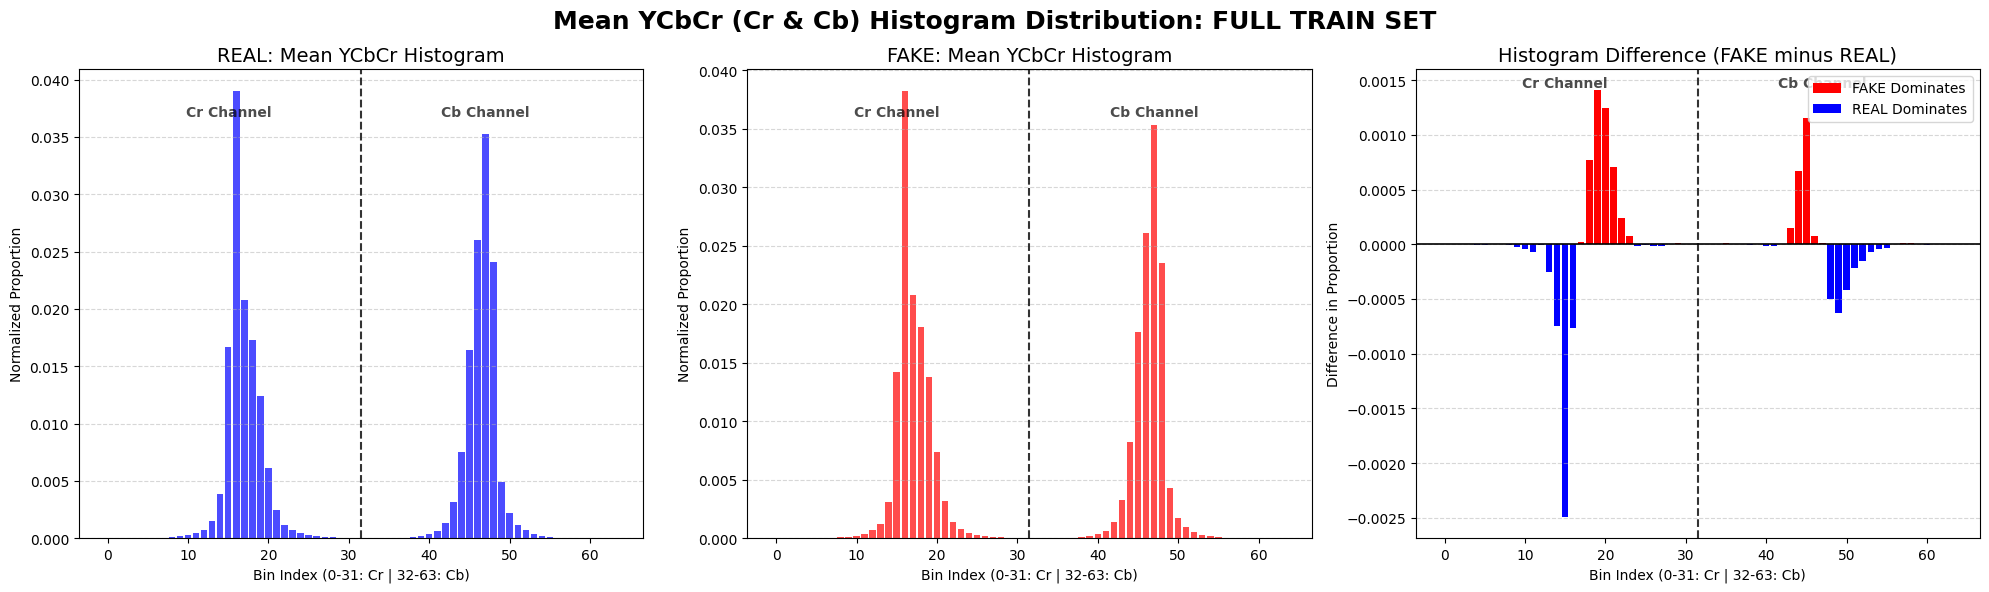

In [8]:
def get_ycbcr_histograms(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return None
        
    img_ycbcr = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    
    cr_hist, _ = np.histogram(img_ycbcr[:,:,1].ravel(), bins=32, range=(0, 256), density=True)
    cb_hist, _ = np.histogram(img_ycbcr[:,:,2].ravel(), bins=32, range=(0, 256), density=True)
    
    return np.concatenate([cr_hist, cb_hist])

def process_ycbcr_parallel(paths, desc):
    histograms = []
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = executor.map(get_ycbcr_histograms, paths)
        for hist in tqdm(futures, total=len(paths), desc=desc):
            if hist is not None:
                histograms.append(hist)
    return np.mean(np.array(histograms), axis=0)

real_ycbcr_mean = process_ycbcr_parallel(CONFIG["TRAIN_PATHS"]["REAL"], desc="YCbCr REAL images")
fake_ycbcr_mean = process_ycbcr_parallel(CONFIG["TRAIN_PATHS"]["FAKE"], desc="YCbCr FAKE images")

bins = np.arange(64) 
width = 0.8

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Mean YCbCr (Cr & Cb) Histogram Distribution: FULL TRAIN SET", fontsize=18, fontweight='bold')

def add_chroma_labels(ax):
    ax.axvline(x=31.5, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(15, ax.get_ylim()[1]*0.9, 'Cr Channel', horizontalalignment='center', fontweight='bold', alpha=0.7)
    ax.text(47, ax.get_ylim()[1]*0.9, 'Cb Channel', horizontalalignment='center', fontweight='bold', alpha=0.7)

axes[0].bar(bins, real_ycbcr_mean, width=width, color='blue', alpha=0.7)
axes[0].set_title('REAL: Mean YCbCr Histogram', fontsize=14)
axes[0].set_xlabel('Bin Index (0-31: Cr | 32-63: Cb)')
axes[0].set_ylabel('Normalized Proportion')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
add_chroma_labels(axes[0])

axes[1].bar(bins, fake_ycbcr_mean, width=width, color='red', alpha=0.7)
axes[1].set_title('FAKE: Mean YCbCr Histogram', fontsize=14)
axes[1].set_xlabel('Bin Index (0-31: Cr | 32-63: Cb)')
axes[1].set_ylabel('Normalized Proportion')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)
add_chroma_labels(axes[1])

diff_ycbcr = fake_ycbcr_mean - real_ycbcr_mean
colors = ['red' if d > 0 else 'blue' for d in diff_ycbcr]
axes[2].bar(bins, diff_ycbcr, width=width, color=colors)
axes[2].axhline(0, color='black', linewidth=1.2)
axes[2].set_title('Histogram Difference (FAKE minus REAL)', fontsize=14)
axes[2].set_xlabel('Bin Index (0-31: Cr | 32-63: Cb)')
axes[2].set_ylabel('Difference in Proportion')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)
add_chroma_labels(axes[2])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='FAKE Dominates'),
                   Patch(facecolor='blue', label='REAL Dominates')]
axes[2].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

#  YCbCr Color Space Features

---

#### 1. Cơ sở lý thuyết: Loại bỏ kênh Y (Luminance) và Khai thác dải Chrominance
Trong bước thực nghiệm này, nhóm quyết định chuyển đổi dữ liệu từ không gian RGB sang **YCbCr**, đồng thời chủ động loại bỏ hoàn toàn kênh **Y (Luminance - Độ sáng)**. Quyết định này được thúc đẩy bởi hai luận điểm chính trong lĩnh vực Image Forensics:

* **Đặc tính của Hệ thị giác người (Human Visual System - HVS):** Cấu trúc sinh học của mắt người nhạy cảm với độ chói (luminance) cao hơn gấp nhiều lần so với sắc độ (chrominance). Do đó, chúng ta dễ bị đánh lừa bởi những bức ảnh có cấu trúc ánh sáng, bóng đổ tốt.
* **Chiến lược tối ưu của Generative AI:** Các mô hình khuếch tán (Diffusion Models) hay GAN hiện nay được huấn luyện dồn toàn bộ tài nguyên để tái tạo kênh Y cực kỳ hoàn hảo. Nếu nhóm đưa kênh Y vào mô hình phân loại, dữ liệu sẽ bị nhiễu do phân phối kênh Y của ảnh Thật và ảnh Giả gần như đồng nhất. 

**Định hướng:** Điểm yếu của các thuật toán sinh ảnh nằm ở quá trình nội suy màu sắc ở cấp độ vi mô. Những lỗi (artifacts) này sinh ra các vệt nhiễu màu trong kênh **Cr (Chrominance Red)** và **Cb (Chrominance Blue)** - nơi mắt người ít chú ý nhưng phương pháp thống kê có thể bắt được.

## 2. Đánh giá phân phối Histogram (Kênh Cr & Cb)
Dựa trên kết quả trực quan hóa *Histogram Difference (FAKE minus REAL)* trên toàn bộ tập dữ liệu huấn luyện, nhóm ghi nhận sự lệch pha (distribution shift) có ý nghĩa thống kê giữa hai tập mẫu:

* **Kênh Cr (Dải Bin 0 - 31): Hiện tượng "Dư thừa sắc đỏ vi mô"**
    * **Quan sát:** Phân phối của ảnh REAL đạt đỉnh cân bằng tại trung tâm (bin 15). Trong khi đó, ảnh FAKE có xu hướng dịch chuyển hẳn sang bên phải, áp đảo mạnh mẽ tại các bins 18, 19, và 20.

* **Kênh Cb (Dải Bin 32 - 63): Sự thiếu hụt chiều sâu sắc xanh**
    * **Quan sát:** Ở kênh Cb, biểu đồ Difference cho thấy ảnh FAKE chiếm ưu thế ở sườn trái của phổ (quanh bins 44, 45). Ngược lại, ảnh REAL duy trì được cường độ Cb tự nhiên và sắc nét hơn ở các dải cao (bins 49, 50).

## 3. Kết luận
Sự phân tách rõ ràng về mặt phân phối ở cả hai dải Cr và Cb chứng minh rằng việc khai thác không gian màu YCbCr (bỏ Y) là một hướng đi hoàn toàn chính xác. Vector 64-chiều (32 bins Cr + 32 bins Cb) này là một feature có chất lượng phân cụm cao.
